In [2]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
    # =========================
    # 2. LOAD DATASET
    # =========================
    df = pd.read_csv(
        "IMDB_Dataset.csv",
        encoding_errors='ignore',
        on_bad_lines='skip',
        engine='python'
    )
    
    print("Dataset Loaded ✅")

Dataset Loaded ✅


In [6]:
# =========================
# 3. DATA CLEANING
# =========================
df = df.dropna()
df.columns = ['review', 'sentiment']


In [8]:
# =========================
# 4. TEXT PREPROCESSING
# =========================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)        # Remove HTML tags
    text = re.sub(r'[^a-zA-Z ]', '', text)   # Remove special chars
    return text

df['review'] = df['review'].apply(clean_text)

In [10]:
# =========================
# 5. LABEL ENCODING
# =========================
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("\nSentiment Count:")
print(df['sentiment'].value_counts())


Sentiment Count:
sentiment
0    24813
1    24799
Name: count, dtype: int64


In [12]:
# =========================
# 6. TF-IDF VECTORIZATION
# =========================
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['review']).toarray()
y = df['sentiment']

In [14]:
# =========================
# 7. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# =========================
# 8. BUILD DNN MODEL
# =========================
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# =========================
# 9. EARLY STOPPING
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [20]:
# =========================
# 10. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8552 - loss: 0.3388 - val_accuracy: 0.8928 - val_loss: 0.2592
Epoch 2/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9075 - loss: 0.2348 - val_accuracy: 0.8891 - val_loss: 0.2678
Epoch 3/10
1241/1241 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9250 - loss: 0.1952 - val_accuracy: 0.8858 - val_loss: 0.2811


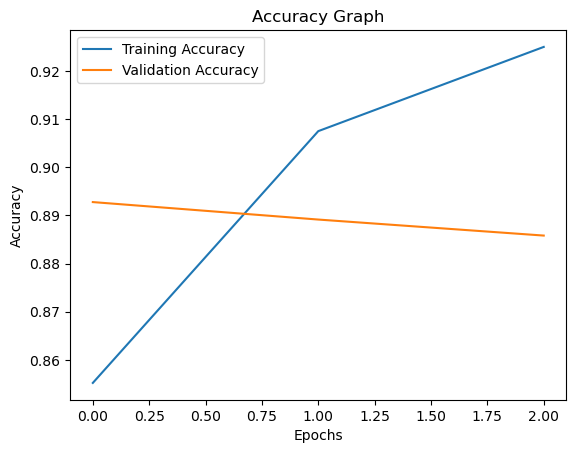

In [26]:
# =========================
# 11. PLOT GRAPH
# =========================
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()